In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded files.upload()

Saving covid19_Confirmed_dataset.csv to covid19_Confirmed_dataset.csv
Saving covid19_deaths_dataset.csv to covid19_deaths_dataset.csv
Saving worldwide_happiness_report.csv to worldwide_happiness_report.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

confirmed_df = pd.read_csv("covid19_Confirmed_dataset.csv")
deaths_df = pd.read_csv("covid19_deaths_dataset.csv")
happiness_df = pd.read_csv("worldwide_happiness_report.csv")

print("Confirmed Cases:")
display(confirmed_df.head())

print("Deaths:")
display(deaths_df.head())

print("Happiness Report:")
display(happiness_df.head())

Confirmed Cases:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,1092,1176,1279,1351,1463,1531,1703,1828,1939,2171
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,609,634,663,678,712,726,736,750,766,773
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,2811,2910,3007,3127,3256,3382,3517,3649,3848,4006
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,717,723,723,731,738,738,743,743,743,745
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,24,25,25,25,25,26,27,27,27,27


Deaths:


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,4/21/20,4/22/20,4/23/20,4/24/20,4/25/20,4/26/20,4/27/20,4/28/20,4/29/20,4/30/20
0,NaN,Afghanistan,33.0000,65.0000,0,0,0,0,0,0,...,36,40,42,43,47,50,57,58,60,64
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,26,27,27,27,27,28,28,30,30,31
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,392,402,407,415,419,425,432,437,444,450
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,37,37,37,40,40,40,40,41,42,42
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2


Happiness Report:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [ ]:
confirmed_numeric = confirmed_df.drop(columns=["Province/State", "Lat", "Long"], errors="ignore")
deaths_numeric = deaths_df.drop(columns=["Province/State", "Lat", "Long"], errors="ignore")

confirmed_country = confirmed_numeric.groupby("Country/Region").sum()
deaths_country = deaths_numeric.groupby("Country/Region").sum()

confirmed_country["Total_Cases"] = confirmed_country.iloc[:, -1]
deaths_country["Total_Deaths"] = deaths_country.iloc[:, -1]

covid_summary = confirmed_country[["Total_Cases"]].merge(deaths_country[["Total_Deaths"]], left_index=True, right_index=True)
covid_summary.reset_index(inplace=True)
covid_summary.rename(columns={"Country/Region": "Country"}, inplace=True)

display(covid_summary.head())

,Country,Total_Cases,Total_Deaths
0,Afghanistan,2171,64
1,Albania,773,31
2,Algeria,4006,450
3,Andorra,745,42
4,Angola,27,2


/tmp/ipython-input-3037649071.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Total_Cases", data=top_cases, palette="coolwarm")


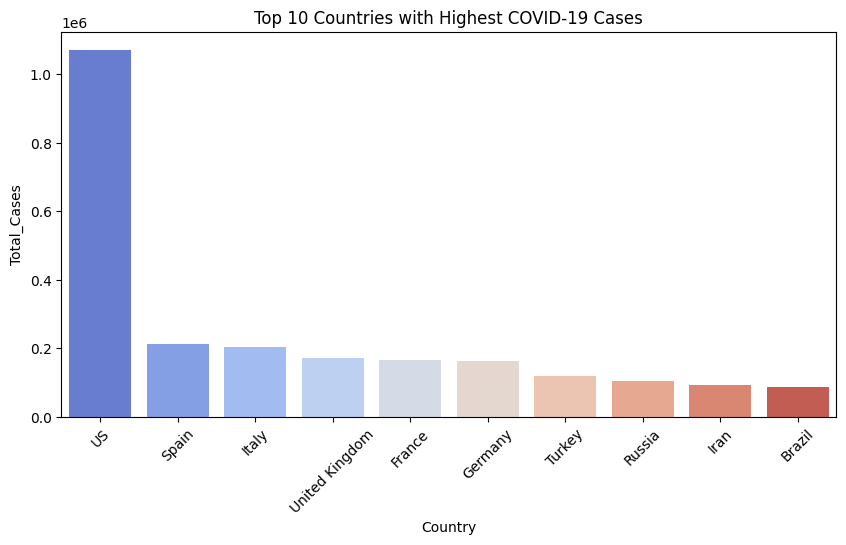

/tmp/ipython-input-3037649071.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Total_Deaths", data=top_deaths, palette="Reds_r")


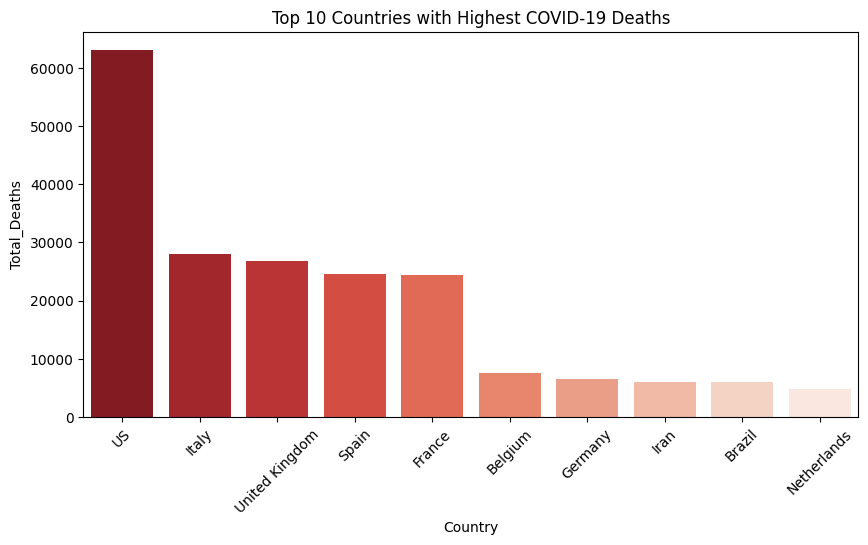

In [ ]:
top_cases = covid_summary.sort_values(by="Total_Cases", ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x="Country", y="Total_Cases", data=top_cases, palette="coolwarm")
plt.title("Top 10 Countries with Highest COVID-19 Cases")
plt.xticks(rotation=45)
plt.show()

top_deaths = covid_summary.sort_values(by="Total_Deaths", ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x="Country", y="Total_Deaths", data=top_deaths, palette="Reds_r")
plt.title("Top 10 Countries with Highest COVID-19 Deaths")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Happiness columns:", happiness_df.columns.tolist())
print("COVID summary columns:", covid_summary.columns.tolist())

Happiness columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social_support', 'Life_expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
COVID summary columns: ['Country', 'Total_Cases', 'Total_Deaths']


In [ ]:
happiness_df.rename(columns={"Country name": "Country"}, inplace=True)
covid_summary.rename(columns={"Country/Region": "Country"}, inplace=True)  # usually already renamed

In [ ]:
for col in happiness_df.columns:
    print(repr(col))

for col in covid_summary.columns:
    print(repr(col))

'Overall rank'
'Country or region'
'Score'
'GDP per capita'
'Social_support'
'Life_expectancy'
'Freedom to make life choices'
'Generosity'
'Perceptions of corruption'
'Country'
'Total_Cases'
'Total_Deaths'


In [ ]:
happiness_df.columns = happiness_df.columns.str.strip()
covid_summary.columns = covid_summary.columns.str.strip()

if "Country name" in happiness_df.columns:
    happiness_df.rename(columns={"Country name": "Country"}, inplace=True)

In [ ]:
print("Happiness columns:", list(happiness_df.columns))
print("COVID summary columns:", list(covid_summary.columns))

Happiness columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social_support', 'Life_expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
COVID summary columns: ['Country', 'Total_Cases', 'Total_Deaths']


In [ ]:
happiness_df.columns = happiness_df.columns.str.strip()
covid_summary.columns = covid_summary.columns.str.strip()
happiness_df.columns = happiness_df.columns.str.lower()
covid_summary.columns = covid_summary.columns.str.lower()

happiness_df.rename(columns={"country name": "Country"}, inplace=True)
covid_summary.rename(columns={"country/region": "Country or region"}, inplace=True)

print("Happiness columns after rename:", list(happiness_df.columns))
print("COVID columns after rename:", list(covid_summary.columns))

Happiness columns after rename: ['overall rank', 'country or region', 'score', 'gdp per capita', 'social_support', 'life_expectancy', 'freedom to make life choices', 'generosity', 'perceptions of corruption']
COVID columns after rename: ['country', 'total_cases', 'total_deaths']


In [ ]:
print("Happiness columns:", happiness_df.columns.tolist())
print("COVID summary columns:", covid_summary.columns.tolist())

Happiness columns: ['overall rank', 'country or region', 'score', 'gdp per capita', 'social_support', 'life_expectancy', 'freedom to make life choices', 'generosity', 'perceptions of corruption']
COVID summary columns: ['country', 'total_cases', 'total_deaths']


In [ ]:
happiness_df.rename(columns={"country or region": "country"}, inplace=True)

merged_df = pd.merge(happiness_df, covid_summary, on="country", how="inner")
display(merged_df.head())

,overall rank,country,score,gdp per capita,social_support,life_expectancy,freedom to make life choices,generosity,perceptions of corruption,total_cases,total_deaths
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,4995,211
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,9356,452
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,7738,210
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,1797,10
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,39512,4811


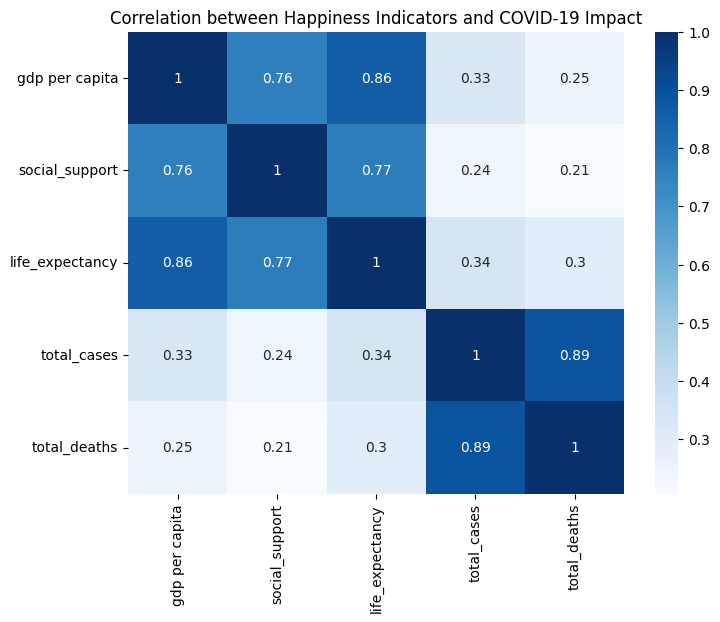

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_columns = ["gdp per capita", "social_support", "life_expectancy", "total_cases", "total_deaths"]

corr = merged_df[corr_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation between Happiness Indicators and COVID-19 Impact")
plt.show()

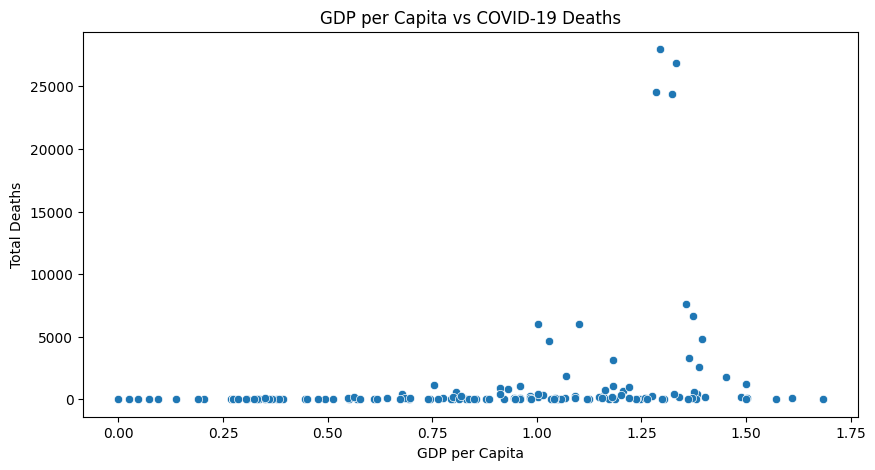

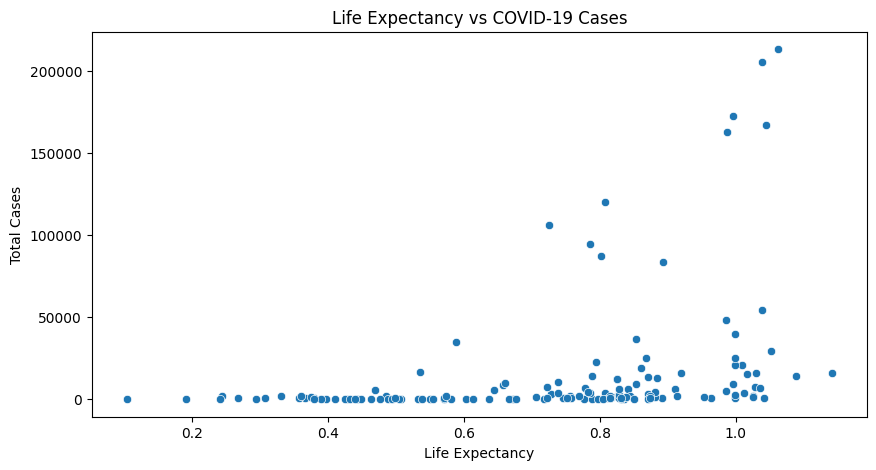

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="gdp per capita", y="total_deaths", data=merged_df)
plt.title("GDP per Capita vs COVID-19 Deaths")
plt.xlabel("GDP per Capita")
plt.ylabel("Total Deaths")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="life_expectancy", y="total_cases", data=merged_df)
plt.title("Life Expectancy vs COVID-19 Cases")
plt.xlabel("Life Expectancy")
plt.ylabel("Total Cases")
plt.show()